# 07 — EDA датасета DialogSum-RU (d0rj/dialogsum-ru)

Этот ноутбук — самостоятельный (Jupyter / Google Colab) разведочный анализ датасета [`d0rj/dialogsum-ru`](https://huggingface.co/datasets/d0rj/dialogsum-ru): русскоязычной версии DialogSum с диалогами и их короткими резюме.

**Схема датасета** (фиксированная, подтверждена пользователем): `id`, `dialogue`, `summary`, `topic`.

**Цель:** понять структуру данных, распределения длин, баланс тем и качество текста, чтобы спланировать дальнейшее моделирование (суммаризация, классификация тем/намерений, иерархические интенты и т.д.).

В ноутбуке **только EDA**: загрузка данных, визуализации и базовые статистики. Никакого обучения моделей здесь нет.

**Источник данных (parquet через `hf://`):**
- `train`: `data/train-00000-of-00001-bcc43b46acda4001.parquet`
- `validation`: `data/validation-00000-of-00001-7e263d81db1c7a12.parquet`
- `test`: `data/test-00000-of-00001-2f13615b955ea947.parquet`


## 1. Импорты и настройки

In [26]:
# При необходимости в Colab могут потребоваться свежие версии pandas/pyarrow/huggingface_hub
# Раскомментируйте строку ниже, если чтение hf://... вернёт ошибку зависимостей:
# !pip install -q -U pandas pyarrow huggingface_hub fsspec

import re
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 200)

sns.set(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Фиксированная схема датасета d0rj/dialogsum-ru
ID_COL       = 'id'
DIALOGUE_COL = 'dialogue'
SUMMARY_COL  = 'summary'
TOPIC_COL    = 'topic'
KNOWN_COLS   = [ID_COL, DIALOGUE_COL, SUMMARY_COL, TOPIC_COL]

print('pandas:', pd.__version__)
print('numpy :', np.__version__)


pandas: 3.0.3
numpy : 2.0.2


## 2. Загрузка train/validation/test

In [27]:
BASE_PATH = 'hf://datasets/d0rj/dialogsum-ru/'
splits = {
    'train':      'data/train-00000-of-00001-bcc43b46acda4001.parquet',
    'validation': 'data/validation-00000-of-00001-7e263d81db1c7a12.parquet',
    'test':       'data/test-00000-of-00001-2f13615b955ea947.parquet',
}

dfs = {}
for name, rel_path in splits.items():
    url = BASE_PATH + rel_path
    print(f'Loading {name}: {url}')
    dfs[name] = pd.read_parquet(url)

df_train = dfs['train']
df_val   = dfs['validation']
df_test  = dfs['test']

for name, df in dfs.items():
    print(f'{name:>10}: shape = {df.shape}')


Loading train: hf://datasets/d0rj/dialogsum-ru/data/train-00000-of-00001-bcc43b46acda4001.parquet
Loading validation: hf://datasets/d0rj/dialogsum-ru/data/validation-00000-of-00001-7e263d81db1c7a12.parquet
Loading test: hf://datasets/d0rj/dialogsum-ru/data/test-00000-of-00001-2f13615b955ea947.parquet
     train: shape = (12460, 4)
validation: shape = (500, 4)
      test: shape = (1500, 4)


In [28]:
for name, df in dfs.items():
    print(f'\n=== {name} — head(3) ===')
    display(df.head(3))



=== train — head(3) ===


,id,dialogue,summary,topic
0,train_0,"#Person1#: Привет, мистер Смит. Я доктор Хокинс. Почему ты здесь сегодня?\n#Person2#: Я решил, что было бы неплохо пройти обследование.\n#Person1#: Да ну, у тебя его уже 5 лет нет. Вы должны иметь...","Мистер Смит проходит обследование, и доктор Хокинс советует ему проходить его каждый год. Хокинс расскажет об их занятиях и лекарствах, которые помогут мистеру Смиту бросить курить.",пройти обследование
1,train_1,"#Person1#: Здравствуйте, миссис Паркер, как дела?\n#Person2#: Здравствуйте, доктор Питерс. Просто отлично спасибо. Рикки и я здесь за его вакцинами.\n#Person1#: Очень хорошо. Давайте посмотрим, со...","Миссис Паркер берет Рики на прививки. Доктор Питерс проверяет записи, а затем делает Рики вакцину.",вакцина
2,train_2,"#Person1#: Простите, вы не видели связку ключей?\n#Person2#: Что за ключи?\n#Person1#: Пять ключей и маленькое украшение для ног.\n#Person2#: Какой позор! Я их не видел.\n#Person1#: Ну, поможешь п...",#Person1# ищет набор ключей и просит #Person2# помочь их найти.,найти ключи



=== validation — head(3) ===


,id,dialogue,summary,topic
0,dev_0,"#Person1#: Привет, как дела сегодня?\n#Person2#: В последнее время у меня проблемы с дыханием.\n#Person1#: Вы простудились в последнее время?\n#Person2#: Нет, простуды не было. Я просто чувствую т...",У #Person2# проблемы с дыханием. Врач спрашивает об этом #Person2# и направляет #Person2# к пульмонологу.,обратиться к врачу
1,dev_1,"#Person1#: Привет, Джимми. Давай потренируемся сегодня позже.\n#Person2#: Конечно. В какое время ты хочешь пойти?\n#Person1#: Как насчет 3:30?\n#Person2#: Звучит неплохо. Сегодня мы работаем над Н...",#Person1# приглашает Джимми на тренировку и уговаривает его потренировать руки и живот.,делать упражнения
2,dev_2,"#Person1#: Мне нужно перестать есть такую ​​нездоровую пищу.\n#Person2#: Я понимаю, что ты имеешь в виду. Я сама стала лучше есть.\n#Person1#: Что ты сейчас ешь?\n#Person2#: Я предпочитаю фрукты, ...","#Person1# планирует перестать есть нездоровую пищу, а #Person2# делится рецептом здорового питания #Person2# с #Person1#.",Здоровая пища



=== test — head(3) ===


,id,dialogue,summary,topic
0,test_0_1,"#Person1#: Мисс Доусон, мне нужно, чтобы вы сделали мне диктант.\n#Person2#: Да, сэр...\n#Person1#: Это должно быть опубликовано в качестве внутриофисного меморандума для всех сотрудников к сегодн...","Г-жа Доусон помогает #Person1# написать записку, чтобы проинформировать каждого сотрудника о том, что им нужно изменить способ связи и им больше не следует использовать мгновенные сообщения.",способ связи
1,test_0_2,"#Person1#: Мисс Доусон, мне нужно, чтобы вы сделали мне диктант.\n#Person2#: Да, сэр...\n#Person1#: Это должно быть опубликовано в качестве внутриофисного меморандума для всех сотрудников к сегодн...","Чтобы сотрудники не тратили время на программы мгновенных сообщений, #Person1# решает прекратить использование этих программ и просит г-жу Доусон разослать служебную записку всем сотрудникам до по...",политика компании
2,test_0_3,"#Person1#: Мисс Доусон, мне нужно, чтобы вы сделали мне диктант.\n#Person2#: Да, сэр...\n#Person1#: Это должно быть опубликовано в качестве внутриофисного меморандума для всех сотрудников к сегодн...","Мисс Доусон диктует #Person1# запрет на использование программ мгновенного обмена сообщениями в офисе. Они спорят о его целесообразности, но #Person1# все равно настаивает.",диктант


## 3. Обзор схемы и базовые статистики

In [29]:
print('Ожидаемая схема:', KNOWN_COLS)
print('Колонки train :', list(df_train.columns))
print()
print('dtypes (train):')
print(df_train.dtypes)
print()
print('Пропуски (isna) по сплитам:')
for name, df in dfs.items():
    print(f'\n--- {name} ---')
    print(df[KNOWN_COLS].isna().sum())


Ожидаемая схема: ['id', 'dialogue', 'summary', 'topic']
Колонки train : ['id', 'dialogue', 'summary', 'topic']

dtypes (train):
id          str
dialogue    str
summary     str
topic       str
dtype: object

Пропуски (isna) по сплитам:

--- train ---
id          0
dialogue    0
summary     0
topic       0
dtype: int64

--- validation ---
id          0
dialogue    0
summary     0
topic       0
dtype: int64

--- test ---
id          0
dialogue    0
summary     0
topic       0
dtype: int64


In [30]:
print('=== Один пример строки (train iloc[0]) ===')
row = df_train.iloc[0]
for col in KNOWN_COLS:
    val_str = str(row[col])
    if len(val_str) > 500:
        val_str = val_str[:500] + ' ...[truncated]'
    print(f'\n[{col}]')
    print(val_str)


=== Один пример строки (train iloc[0]) ===

[id]
train_0

[dialogue]
#Person1#: Привет, мистер Смит. Я доктор Хокинс. Почему ты здесь сегодня?
#Person2#: Я решил, что было бы неплохо пройти обследование.
#Person1#: Да ну, у тебя его уже 5 лет нет. Вы должны иметь один каждый год.
#Person2#: Я знаю. Я так понимаю, если ничего страшного, то зачем идти к врачу?
#Person1#: Что ж, лучший способ избежать серьезных заболеваний — узнать о них заранее. Так что старайтесь приезжать хотя бы раз в год для вашего же блага.
#Person2#: Хорошо.
#Person1#: Дай-ка сюда посмотреть. ...[truncated]

[summary]
Мистер Смит проходит обследование, и доктор Хокинс советует ему проходить его каждый год. Хокинс расскажет об их занятиях и лекарствах, которые помогут мистеру Смиту бросить курить.

[topic]
пройти обследование


In [31]:
# Уникальность id по сплитам
for name, df in dfs.items():
    n_unique = df[ID_COL].nunique(dropna=False)
    print(f'{name:>10} [id]: unique={n_unique}, rows={len(df)}, dup={len(df) - n_unique}')


     train [id]: unique=12460, rows=12460, dup=0
validation [id]: unique=500, rows=500, dup=0
      test [id]: unique=1500, rows=1500, dup=0


## 4. Анализ тем (topic): сколько их и как распределены

In [32]:
# Главный вопрос пользователя: «сколько получается topic»
n_topics_train = df_train[TOPIC_COL].nunique(dropna=False)
print(f'Уникальных тем в train: {n_topics_train}')

print('\nУникальные темы в train:')
unique_topics_train = sorted(df_train[TOPIC_COL].dropna().unique().tolist())
if len(unique_topics_train) <= 50:
    for t in unique_topics_train:
        print(f'  - {t}')
else:
    print(f'  (слишком много — {len(unique_topics_train)} тем, ниже выводится top 50 по частоте)')

print('\nvalue_counts(topic) — train (dropna=False):')
print(df_train[TOPIC_COL].value_counts(dropna=False).head(50))


Уникальных тем в train: 6726

Уникальные темы в train:
  (слишком много — 6726 тем, ниже выводится top 50 по частоте)

value_counts(topic) — train (dropna=False):
topic
Покупка                           186
собеседование                     161
ежедневный случайный разговор     125
телефонный звонок                  91
заказать еду                       90
интервью                           78
спросить дорогу                    62
ежедневный разговор                58
светская встреча                   56
обратиться к врачу                 54
деловой разговор                   53
работа                             48
приглашение                        45
регистрироваться                   44
погода                             43
фильм                              36
встреча                            36
запросить информацию               35
непринужденная светская беседа     35
идти за покупками                  33
возьми такси                       29
свадьба                          

In [33]:
# Количество уникальных тем по всем сплитам
print('Уникальных тем по сплитам:')
for name, df in dfs.items():
    print(f'  {name:>10}: nunique = {df[TOPIC_COL].nunique(dropna=False)}')

# Объединённый список тем
all_topics = set()
for df in dfs.values():
    all_topics.update(df[TOPIC_COL].dropna().unique().tolist())
print(f'\nОбъединённое число уникальных тем (train ∪ val ∪ test): {len(all_topics)}')

# Темы, которых нет в train, но есть в val/test
train_topics = set(df_train[TOPIC_COL].dropna().unique())
val_only  = set(df_val[TOPIC_COL].dropna().unique())  - train_topics
test_only = set(df_test[TOPIC_COL].dropna().unique()) - train_topics
print(f'Тем в validation, отсутствующих в train: {len(val_only)}')
print(f'Тем в test,        отсутствующих в train: {len(test_only)}')
if val_only:
    print('  validation-only (top 20):', list(val_only)[:20])
if test_only:
    print('  test-only        (top 20):', list(test_only)[:20])


Уникальных тем по сплитам:
       train: nunique = 6726
  validation: nunique = 443
        test: nunique = 1079

Объединённое число уникальных тем (train ∪ val ∪ test): 7644
Тем в validation, отсутствующих в train: 229
Тем в test,        отсутствующих в train: 696
  validation-only (top 20): ['купить продукт', 'аллергическая реакция', 'чайная культура', 'купить учебники', 'электронные открытки', 'заказ в ресторане', 'прерывание', 'случайные разговоры', 'Обама', 'начать бежать', 'беспокоиться о друзьях', 'с помощью мобильного телефона', 'отменить бронирование отеля', 'ближайший кинотеатр', 'спор между друзьями', 'идти на пляж', 'НЛО и инопланетяне', 'подвезти', 'красивая каллиграфия', 'ноутбук']
  test-only        (top 20): ['Спроси дорогу', 'звонок коллеги', 'украшение кухни', 'выбор костюма на вечеринку', 'сбой питания', 'разговор с сотрудником', 'учебные пособия', 'комментарии к боссу', 'мнение о землетрясении', 'ошибки в товарах', 'информационная служба', 'обсуждение трудовой жизни

In [34]:
# Кросс-таблица topic x split (top 30 наиболее частых тем по суммарной частоте)
combined_topics = pd.concat(
    [df.assign(split=name)[['split', TOPIC_COL]] for name, df in dfs.items()],
    ignore_index=True,
)
ct = pd.crosstab(combined_topics[TOPIC_COL], combined_topics['split'])
ct = ct[['train', 'validation', 'test']]
top_topics = ct.sum(axis=1).sort_values(ascending=False).head(30).index
print('=== Кросс-таблица topic x split (top 30 по суммарной частоте) ===')
display(ct.loc[top_topics])


=== Кросс-таблица topic x split (top 30 по суммарной частоте) ===


split,train,validation,test
topic,,,
Покупка,186,4,19
собеседование,161,11,15
ежедневный случайный разговор,125,1,2
заказать еду,90,4,12
телефонный звонок,91,0,7
спросить дорогу,62,3,18
интервью,78,1,4
ежедневный разговор,58,1,5
светская встреча,56,2,3


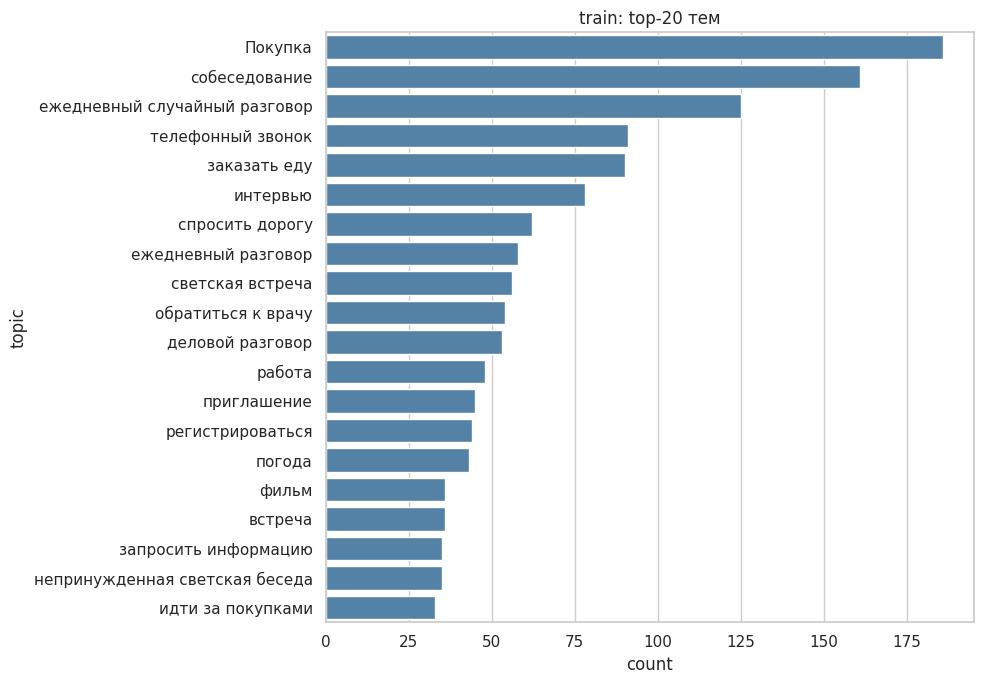

In [35]:
# Бар-плот: top-20 тем в train
top_n = 20
vc_train = df_train[TOPIC_COL].value_counts(dropna=False).head(top_n)
fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(vc_train))))
sns.barplot(x=vc_train.values, y=vc_train.index.astype(str), ax=ax, color='steelblue')
ax.set_title(f'train: top-{top_n} тем')
ax.set_xlabel('count')
plt.tight_layout()
plt.show()


## 5. Анализ длин диалогов и резюме

In [36]:
_TOKEN_RE = re.compile(r'\w+', flags=re.UNICODE)

def count_tokens(text):
    if not isinstance(text, str) or not text:
        return 0
    return len(_TOKEN_RE.findall(text))

def count_chars(text):
    if not isinstance(text, str):
        return 0
    return len(text)

def count_dialogue_lines(text):
    if not isinstance(text, str) or not text:
        return 0
    return len([ln for ln in re.split(r'[\r\n]+', text) if ln.strip()])

def add_length_features(df):
    df = df.copy()
    df['dialogue_len_tokens'] = df[DIALOGUE_COL].apply(count_tokens)
    df['summary_len_tokens']  = df[SUMMARY_COL].apply(count_tokens)
    df['dialogue_len_chars']  = df[DIALOGUE_COL].apply(count_chars)
    df['summary_len_chars']   = df[SUMMARY_COL].apply(count_chars)
    df['dialogue_n_lines']    = df[DIALOGUE_COL].apply(count_dialogue_lines)
    df['compression_rate']    = np.where(
        df['dialogue_len_tokens'] > 0,
        df['summary_len_tokens'] / df['dialogue_len_tokens'],
        np.nan,
    )
    return df

dfs_feat = {name: add_length_features(df) for name, df in dfs.items()}
df_train_f = dfs_feat['train']
df_val_f   = dfs_feat['validation']
df_test_f  = dfs_feat['test']

stat_cols = ['dialogue_len_tokens', 'summary_len_tokens',
             'dialogue_len_chars', 'summary_len_chars',
             'dialogue_n_lines', 'compression_rate']

for name, df in dfs_feat.items():
    print(f'\n=== {name} — describe ===')
    display(df[stat_cols].describe().round(3))



=== train — describe ===


,dialogue_len_tokens,summary_len_tokens,dialogue_len_chars,summary_len_chars,dialogue_n_lines,compression_rate
count,12460.000,12460.000,12460.000,12460.000,12460.000,12460.000
mean,113.426,20.418,737.455,145.055,9.494,0.192
std,62.665,9.887,402.535,69.120,4.157,0.057
min,25.000,4.000,178.000,30.000,2.000,0.042
25%,73.000,13.000,479.000,97.000,7.000,0.156
50%,100.000,19.000,650.000,132.000,9.000,0.185
75%,141.000,25.000,916.250,178.250,12.000,0.218
max,871.000,137.000,5158.000,1073.000,61.000,0.842



=== validation — describe ===


,dialogue_len_tokens,summary_len_tokens,dialogue_len_chars,summary_len_chars,dialogue_n_lines,compression_rate
count,500.000,500.000,500.000,500.000,500.000,500.000
mean,111.976,18.644,726.358,134.270,9.380,0.177
std,58.790,9.155,372.551,63.988,3.992,0.054
min,28.000,5.000,201.000,40.000,2.000,0.073
25%,72.000,12.000,466.000,88.000,6.000,0.140
50%,98.000,16.000,645.000,119.000,9.000,0.169
75%,140.000,23.000,906.500,166.250,12.000,0.203
max,416.000,61.000,2587.000,458.000,29.000,0.541



=== test — describe ===


,dialogue_len_tokens,summary_len_tokens,dialogue_len_chars,summary_len_chars,dialogue_n_lines,compression_rate
count,1500.000,1500.000,1500.000,1500.000,1500.000,1500.000
mean,116.532,16.414,757.092,116.691,9.706,0.155
std,66.788,7.898,428.107,54.377,4.987,0.058
min,29.000,4.000,190.000,23.000,2.000,0.046
25%,70.750,11.000,469.250,78.750,7.000,0.116
50%,104.000,15.000,670.500,108.000,9.000,0.142
75%,144.250,20.000,954.250,142.000,12.000,0.181
max,679.000,71.000,4348.000,491.000,65.000,0.533


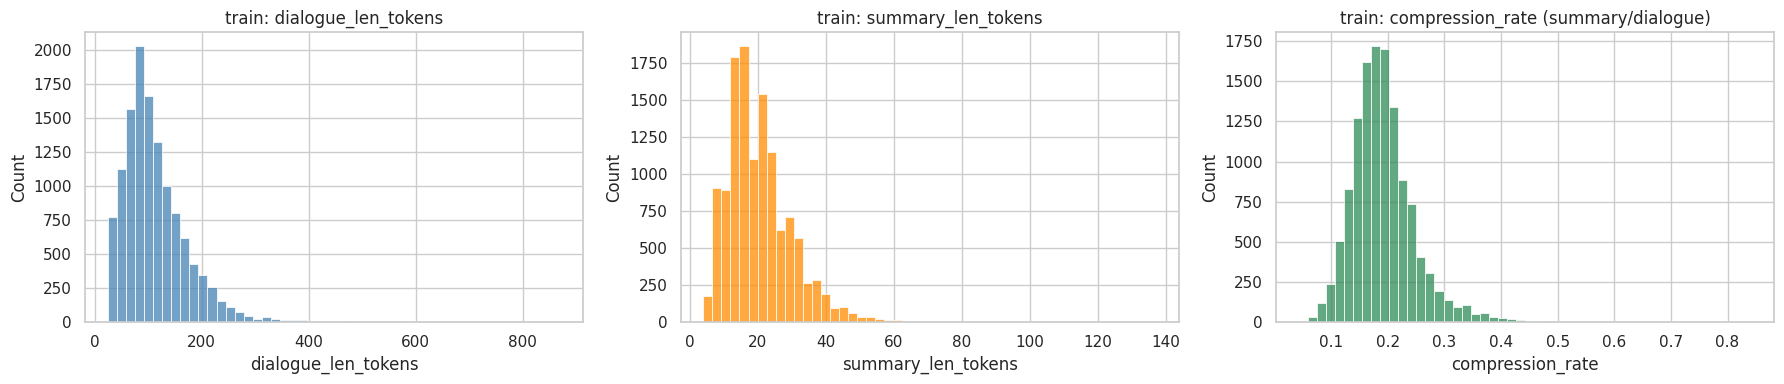

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(df_train_f['dialogue_len_tokens'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('train: dialogue_len_tokens')
sns.histplot(df_train_f['summary_len_tokens'], bins=50, ax=axes[1], color='darkorange')
axes[1].set_title('train: summary_len_tokens')
sns.histplot(df_train_f['compression_rate'].dropna(), bins=50, ax=axes[2], color='seagreen')
axes[2].set_title('train: compression_rate (summary/dialogue)')
plt.tight_layout()
plt.show()


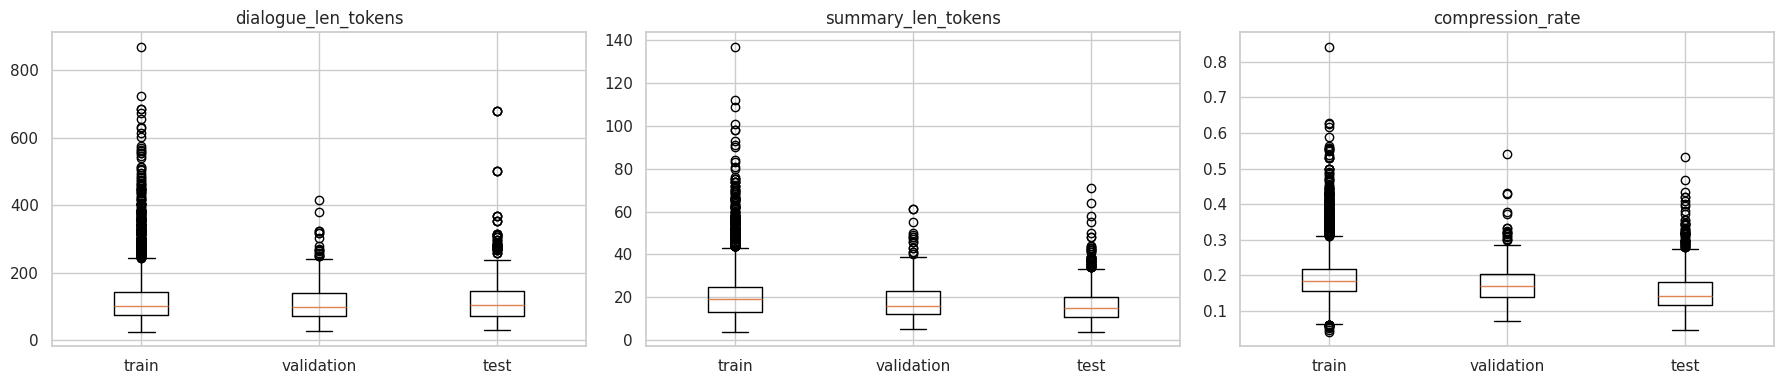

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ['dialogue_len_tokens', 'summary_len_tokens', 'compression_rate']):
    data = [dfs_feat[s][col].dropna() for s in ['train', 'validation', 'test']]
    ax.boxplot(data, labels=['train', 'validation', 'test'])
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 6. Качество текста: пропуски, дубликаты, спецсимволы

In [39]:
print('=== Пропуски / пустые строки по сплитам (по 4 известным колонкам) ===')
for name, df in dfs.items():
    n_total = len(df)
    stats = {}
    for col in KNOWN_COLS:
        n_na = df[col].isna().sum()
        n_empty = (df[col].fillna('').astype(str).str.strip() == '').sum()
        stats[col] = (int(n_na), int(n_empty))
    line = ', '.join(f'{c}: NaN={n}, empty={e}' for c, (n, e) in stats.items())
    print(f'{name:>10} (rows={n_total}): {line}')


=== Пропуски / пустые строки по сплитам (по 4 известным колонкам) ===
     train (rows=12460): id: NaN=0, empty=0, dialogue: NaN=0, empty=0, summary: NaN=0, empty=0, topic: NaN=0, empty=0
validation (rows=500): id: NaN=0, empty=0, dialogue: NaN=0, empty=0, summary: NaN=0, empty=0, topic: NaN=0, empty=0
      test (rows=1500): id: NaN=0, empty=0, dialogue: NaN=0, empty=0, summary: NaN=0, empty=0, topic: NaN=0, empty=0


In [40]:
print('=== Дубликаты по id и по тексту диалога ===')
for name, df in dfs.items():
    dup_id  = df[ID_COL].duplicated().sum()
    dup_dlg = df[DIALOGUE_COL].duplicated().sum()
    print(f'{name:>10}: duplicated id = {dup_id}, duplicated dialogue text = {dup_dlg}')

# Пересечения id между сплитами
ids_train = set(df_train[ID_COL])
ids_val   = set(df_val[ID_COL])
ids_test  = set(df_test[ID_COL])
print('\nПересечения id между сплитами:')
print(f'  train ∩ validation: {len(ids_train & ids_val)}')
print(f'  train ∩ test      : {len(ids_train & ids_test)}')
print(f'  validation ∩ test : {len(ids_val & ids_test)}')


=== Дубликаты по id и по тексту диалога ===
     train: duplicated id = 0, duplicated dialogue text = 862
validation: duplicated id = 0, duplicated dialogue text = 2
      test: duplicated id = 0, duplicated dialogue text = 1001

Пересечения id между сплитами:
  train ∩ validation: 0
  train ∩ test      : 0
  validation ∩ test : 0


train: cyr_ratio (dialogue) describe:
count    12460.000
mean         0.883
std          0.045
min          0.677
25%          0.856
50%          0.889
75%          0.917
max          0.994
Name: cyr_ratio_dialogue, dtype: float64

train: cyr_ratio (summary) describe:
count    12460.000
mean         0.843
std          0.098
min          0.400
25%          0.779
50%          0.844
75%          0.914
max          1.000
Name: cyr_ratio_summary, dtype: float64

train: с URL — dialogue: 7 , summary: 0
train: avg спецсимволов — dialogue: 19.046 , summary: 5.195


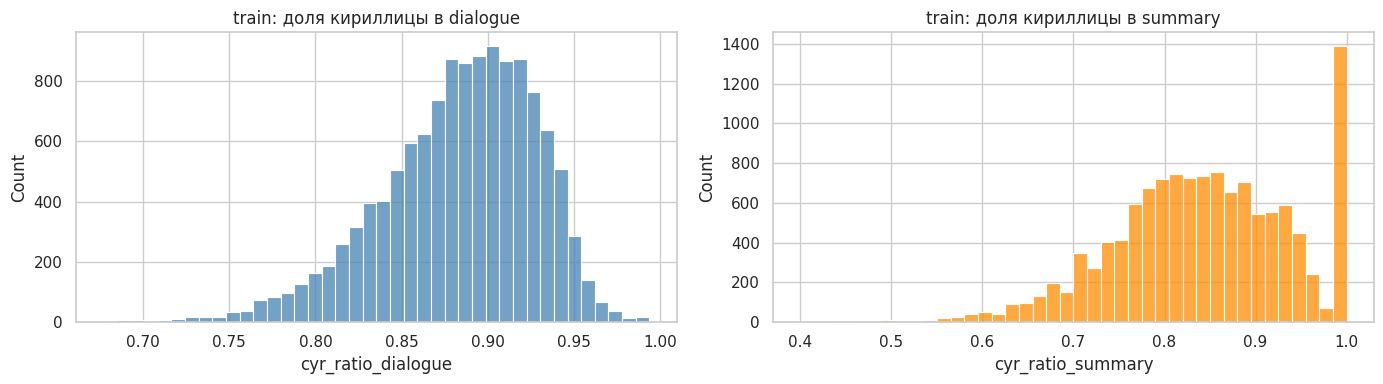

In [41]:
URL_RE     = re.compile(r'https?://|www\.')
SPECIAL_RE = re.compile(r'[#\\<>{}\[\]\^~`|]')
CYR_RE     = re.compile(r'[А-Яа-яЁё]')
LETTER_RE  = re.compile(r'[^\W\d_]', flags=re.UNICODE)

def cyr_ratio(text):
    if not isinstance(text, str) or not text:
        return np.nan
    letters = LETTER_RE.findall(text)
    if not letters:
        return np.nan
    return len(CYR_RE.findall(text)) / len(letters)

qual = df_train_f.copy()
qual['cyr_ratio_dialogue'] = qual[DIALOGUE_COL].apply(cyr_ratio)
qual['cyr_ratio_summary']  = qual[SUMMARY_COL].apply(cyr_ratio)
qual['has_url_dialogue']   = qual[DIALOGUE_COL].fillna('').str.contains(URL_RE)
qual['has_url_summary']    = qual[SUMMARY_COL].fillna('').str.contains(URL_RE)
qual['n_special_dialogue'] = qual[DIALOGUE_COL].fillna('').apply(lambda s: len(SPECIAL_RE.findall(s)))
qual['n_special_summary']  = qual[SUMMARY_COL].fillna('').apply(lambda s: len(SPECIAL_RE.findall(s)))

print('train: cyr_ratio (dialogue) describe:')
print(qual['cyr_ratio_dialogue'].describe().round(3))
print('\ntrain: cyr_ratio (summary) describe:')
print(qual['cyr_ratio_summary'].describe().round(3))
print('\ntrain: с URL — dialogue:', int(qual['has_url_dialogue'].sum()),
      ', summary:', int(qual['has_url_summary'].sum()))
print('train: avg спецсимволов — dialogue:', round(qual['n_special_dialogue'].mean(), 3),
      ', summary:', round(qual['n_special_summary'].mean(), 3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(qual['cyr_ratio_dialogue'].dropna(), bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('train: доля кириллицы в dialogue')
sns.histplot(qual['cyr_ratio_summary'].dropna(), bins=40, ax=axes[1], color='darkorange')
axes[1].set_title('train: доля кириллицы в summary')
plt.tight_layout()
plt.show()


## 7. Случайные примеры и крайние случаи

In [42]:
def show_examples(df, n=5, random_state=SEED):
    sample = df.sample(min(n, len(df)), random_state=random_state)
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        print('=' * 80)
        print(f'Example {i}')
        print(f'  id    : {row[ID_COL]}')
        print(f'  topic : {row[TOPIC_COL]}')
        print('  --- dialogue ---')
        print(row[DIALOGUE_COL])
        print('  --- summary ---')
        print(row[SUMMARY_COL])
    print('=' * 80)

show_examples(df_train, n=5)


Example 1
  id    : train_10562
  topic : новая работа
  --- dialogue ---
#Person1#: Я слышал, что ты нашел замечательную работу на почте. Как продвигается твоя новая работа?
#Person2#: Боюсь, не очень хорошо. Я просто чувствую себя как рыба в воде. Люди там довольно странные для меня.
  --- summary ---
#Person2# не любит новую работу.
Example 2
  id    : train_9191
  topic : занятия на улице
  --- dialogue ---
#Person1#: Мистер Лин, что вас интересует?
#Person2#: Мне нравится кемпинг.
#Person1#: Правда? Я не большой любитель активного отдыха. Что вам нравится в нем?
#Person2#: Я люблю свежий воздух, пейзажи, физические упражнения и время подумать.
#Person1#: Вы ходите в походы или ловите рыбу в своих поездках?
#Person2#: Да, оба. В прошлую поездку я немного порыбачил и прошел пешком пять миль.
#Person1#: Вы что-нибудь поймали?
#Person2#: Да, но я их откинул.
#Person1#: Как насчет того, чтобы присоединиться к нашему летнему лагерю на следующей неделе?
#Person2#: Отлично! Я не могу ждат

In [43]:
print('=== Самые длинные диалоги (train, top 3 by dialogue_len_tokens) ===')
for _, row in df_train_f.nlargest(3, 'dialogue_len_tokens').iterrows():
    print('-' * 80)
    print(f'id: {row[ID_COL]}, topic: {row[TOPIC_COL]}')
    print(f'tokens={row["dialogue_len_tokens"]}, lines={row["dialogue_n_lines"]}')
    text = str(row[DIALOGUE_COL])
    print(text[:1000] + (' ...[truncated]' if len(text) > 1000 else ''))

print('\n=== Самые короткие диалоги (train, bottom 3 by dialogue_len_tokens > 0) ===')
short = df_train_f[df_train_f['dialogue_len_tokens'] > 0].nsmallest(3, 'dialogue_len_tokens')
for _, row in short.iterrows():
    print('-' * 80)
    print(f'id: {row[ID_COL]}, topic: {row[TOPIC_COL]}')
    print(f'tokens={row["dialogue_len_tokens"]}, lines={row["dialogue_n_lines"]}')
    print(row[DIALOGUE_COL])
    print('summary:', row[SUMMARY_COL])


=== Самые длинные диалоги (train, top 3 by dialogue_len_tokens) ===
--------------------------------------------------------------------------------
id: train_7368, topic: депрессия
tokens=871, lines=33
#Person1#: Привет, как дела?
#Person2#: Ну, я думаю, ладно... вроде.
#Person1#: Да, мама сказала, что Дэниел не очень хорошо себя чувствует. Что происходит?
#Person2#: Ну, по какой-то причине я всегда думал, что воспитывать детей будет намного проще, чем это есть на самом деле.
#Person1#: Да, я знаю. Расскажи мне об этом. Что, в чем проблема?
#Person2#: Ну, около шести месяцев он был очень подавлен, и иногда я не могу поднять его утром с постели, чтобы пойти в школу. Он просто кажется таким подавленным. Я просто не могу понять это.
#Person1#: Так это уже полгода продолжается?
#Person2#: Да, как то время от времени, но я не знаю. Я... я просто думал, что это просто пройдет, и я просто думал, что все просто станет, я не знаю, станет лучше.
#Person1#: Да, это не так, это довольно тревожно.

## 8. Сравнение train / validation / test

In [44]:
combined = pd.concat(
    [dfs_feat[s].assign(split=s) for s in ['train', 'validation', 'test']],
    ignore_index=True,
)
print('combined shape:', combined.shape)
print()
print('Размеры сплитов:')
print(combined['split'].value_counts())
print()
print('Статистики длин по сплитам:')
display(
    combined.groupby('split')[['dialogue_len_tokens', 'summary_len_tokens',
                               'dialogue_n_lines', 'compression_rate']]
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .round(3)
)


combined shape: (14460, 11)

Размеры сплитов:
split
train         12460
test           1500
validation      500
Name: count, dtype: int64

Статистики длин по сплитам:


dialogue_len_tokens                         summary_len_tokens                        dialogue_n_lines                       compression_rate                            
                          mean median     std min  max               mean median    std min  max             mean median    std min max             mean median    std    min    max
split                                                                                                                                                                               
test                   116.532  104.0  66.788  29  679             16.414   15.0  7.898   4   71            9.706    9.0  4.987   2  65            0.155  0.142  0.058  0.046  0.533
train                  113.426  100.0  62.665  25  871             20.418   19.0  9.887   4  137            9.494    9.0  4.157   2  61            0.192  0.185  0.057  0.042  0.842
validation             111.976   98.0  58.790  28  416             18.644   16.0  9.155   5   61            9.380    9.0  3.992   2  29            0.177  0.169  0.054  0.073  0.541

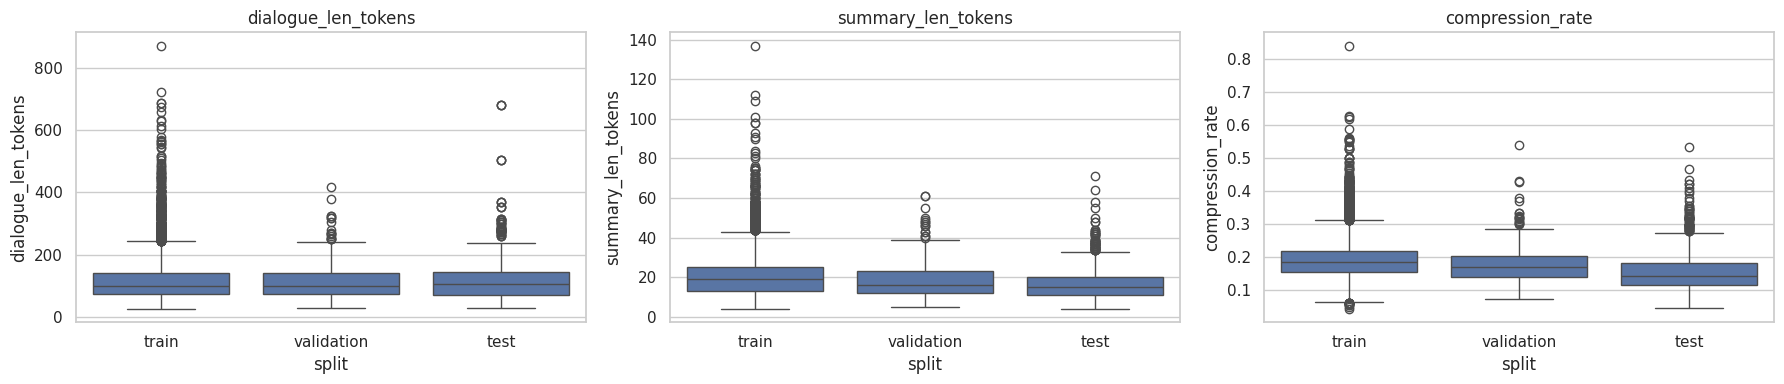

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ['dialogue_len_tokens', 'summary_len_tokens', 'compression_rate']):
    sns.boxplot(data=combined, x='split', y=col,
                order=['train', 'validation', 'test'], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [46]:
# Доли тем по сплитам (top 15 самых частых тем)
ct = pd.crosstab(combined[TOPIC_COL], combined['split'])[['train', 'validation', 'test']]
top_topics = ct.sum(axis=1).sort_values(ascending=False).head(15).index
ct_norm = ct.div(ct.sum(axis=0), axis=1).round(4)
print('=== Доли тем по сплитам (top 15) ===')
display(ct_norm.loc[top_topics])


=== Доли тем по сплитам (top 15) ===


split,train,validation,test
topic,,,
Покупка,0.0149,0.008,0.0127
собеседование,0.0129,0.022,0.0100
ежедневный случайный разговор,0.0100,0.002,0.0013
заказать еду,0.0072,0.008,0.0080
телефонный звонок,0.0073,0.000,0.0047
спросить дорогу,0.0050,0.006,0.0120
интервью,0.0063,0.002,0.0027
ежедневный разговор,0.0047,0.002,0.0033
светская встреча,0.0045,0.004,0.0020


## 9. Краткие выводы и идеи моделирования

## Выводы

- В датасете DialogSum‑RU три сплита: train (12 460 диалогов), validation (500) и test (1 500), во всех сплитах одинаковая схема с четырьмя полями: `id`, `dialogue`, `summary`, `topic`; пропусков в этих колонках нет, идентификаторы уникальны внутри каждого сплита.  
- Колонка `topic` содержит в train 6 726 уникальных значений (всего около 7.6k по трём сплитам), при этом распределение сильно разрежено: много тем встречаются единично, а перекрытие между train/val/test неполное, валидация и тест содержат сотни топиков, которых нет в train.  
- Диалоги довольно длинные: медиана длины train‑диалога около 100 токенов (p75 ≈ 141, максимум 871 токен и до 61 реплики), summaries в среднем около 20 токенов (до 137), при этом коэффициент сжатия в train в среднем примерно 0.19, что близко к оригинальному DIALOGSUM и подтверждает абстрактивный характер задачи.  
- Распределения длины диалогов, summaries и compression rate валидации и теста в целом похожи на train, но в test summaries заметно короче (среднее около 16 токенов и compression rate около 0.155), что стоит учитывать при обучении и оценке моделей.  
- Качественный просмотр примеров показывает, что формат диалогов соответствует исходному DialogSum: реплики помечены `Person1/Person2`, summaries содержат краткое описание ключевых событий и интенций, а `topic` — короткие свободные текстовые описания тем, которые больше подходят для тематического анализа/кластеризации, чем для простой многоклассовой классификации.  
- Для дальнейшей работы логично рассматривать: (1) seq2seq‑модели диалог → summary с учётом длинного входа (chunking или длинные энкодеры), (2) отдельный анализ и тематическое моделирование по `topic` для группировки редких тем, (3) multi‑task‑сценарии, где суммаризация и предсказание укрупнённых topic‑классов обучаются совместно.